In [2]:
import pandas as pd
stats_df = pd.read_csv("intermittedly.csv")

# add bathymetry stats

In [3]:
import os
import xarray as xr
import pandas as pd

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

latlon = stats_df[["lat", "lon"]]
# if you want unique lat/lon pairs:
unique_latlon = latlon.drop_duplicates().to_numpy()

In [4]:
import numpy as np
import xarray as xr

def compute_slope_aspect(ds, var="elevation"):
    
    z = ds[var]

    # grid spacing in degrees
    dlat = float(abs(ds.lat.diff("lat").mean()))
    dlon = float(abs(ds.lon.diff("lon").mean()))

    # convert degrees → meters
    R = 6371000  # Earth radius
    lat_rad = np.deg2rad(ds.lat)

    dy = dlat * np.pi/180 * R
    dx = dlon * np.pi/180 * R * np.cos(lat_rad)

    # compute gradients
    dz_dlat = z.differentiate("lat") / dy
    dz_dlon = z.differentiate("lon") / dx

    # slope (radians → degrees)
    slope = np.arctan(np.sqrt(dz_dlat**2 + dz_dlon**2))
    slope_deg = np.rad2deg(slope)

    # aspect
    aspect = np.arctan2(-dz_dlon, dz_dlat)
    aspect_deg = (np.rad2deg(aspect) + 360) % 360

    return xr.Dataset({
        "slope_deg": slope_deg,
        "aspect_deg": aspect_deg
    })

terrain = compute_slope_aspect(GEBCO_ds)
GEBCO_ds = xr.merge([GEBCO_ds, terrain])

In [5]:
roughness = GEBCO_ds.elevation.rolling(lat=5, lon=5, center=True).std()
GEBCO_ds["roughness"] = roughness

In [6]:
# curvature and curvature in slope direction. pos: convex (ridge), neg: channel
d2z_dx2 = GEBCO_ds.elevation.differentiate("lon").differentiate("lon")
d2z_dy2 = GEBCO_ds.elevation.differentiate("lat").differentiate("lat")

GEBCO_ds["curvature"] = d2z_dx2 + d2z_dy2
GEBCO_ds["profile_curvature"] = d2z_dx2
# BPI value	terrain
#positive	ridge
#negative	valley
#~0	flat
def compute_bpi(ds, window=21):
    mean_z = ds.elevation.rolling(
        lat=window,
        lon=window,
        center=True
    ).mean()

    bpi = ds.elevation - mean_z
    return bpi
GEBCO_ds["bpi"] = compute_bpi(GEBCO_ds, window=21)

/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:228: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [7]:
bpi = GEBCO_ds["bpi"]

GEBCO_ds["bpi_norm"] = (bpi - bpi.mean()) / bpi.std()

In [46]:
import numpy as np

# choose rounding precision that matches your station coordinate precision
# (e.g. 5 decimals ~ 1 m; 4 decimals ~ 11 m; 3 decimals ~ 111 m)
ROUND = 5

def key_ll(lat, lon, ndp=ROUND):
    return (round(float(lat), ndp), round(float(lon), ndp))

# stats_df must have columns like: ["station", "lat", "lon"] (rename below if different)
station_lookup = {
    key_ll(r.lat, r.lon): r.station
    for r in stats_df.itertuples(index=False)
}

In [47]:
import xarray as xr

sizes = {
    "0.1x0.1": 0.1,
    "0.25x0.25": 0.25,
    "1x1": 1.0,
    "3x3": 3.0,
    "10x10": 10.0
}


def attach_station_meta(tile: xr.Dataset, station_id, station_lat, station_lon):
    # coords (not data_vars) is best: lightweight and preserved through most ops
    tile = tile.assign_coords(
        station_id=station_id,
        station_lat=float(station_lat),
        station_lon=float(station_lon),
    )
    # optional: make station_id a scalar coord dimensionless
    return tile


def extract_square(ds, lat, lon, size_deg, var="elevation"):
    half = size_deg / 2

    lat0, lat1 = lat - half, lat + half
    lon0, lon1 = lon - half, lon + half

    # lat slice direction safe
    lat_slice = slice(lat0, lat1) if ds.lat[0] < ds.lat[-1] else slice(lat1, lat0)
    lon_slice = slice(lon0, lon1)

    return ds.sel(lat=lat_slice, lon=lon_slice)


def tile_one_var(ds, lat, lon, size_deg, var):
    # extract spatial box then keep only the variable (and coords)
    tile = extract_square(ds, lat, lon, size_deg)
    tile = tile.where(tile["ocean"])
    return tile[var].where(tile["ocean"])
    #return tile[[var]]  # dataset with just that data_var

# choose variables that are on (lat, lon)
vars_2d = [
    v for v in GEBCO_ds.data_vars
    if set(GEBCO_ds[v].dims) == {"lat", "lon"}
]

results_by_var = {
    v: {k: [] for k in sizes.keys()}
    for v in vars_2d
}

results_all = {k: [] for k in sizes}

ocean = GEBCO_ds["elevation"] <= -0.5
GEBCO_ocean = GEBCO_ds.where(ocean)   # one-time mask

results_by_var = {v: {k: [] for k in sizes} for v in vars_2d}

for lat, lon in unique_latlon:
    k = key_ll(lat, lon)
    if k not in station_lookup:
        # skip or handle however you want
        print(f"WARNING: no station match for lat/lon={k}")
        station_id = np.nan
    else:
        station_id = station_lookup[k]

    for size_key, size_deg in sizes.items():
        tile_all = extract_square(GEBCO_ocean, lat, lon, size_deg)

        # attach station metadata ONCE per tile
        tile_all = attach_station_meta(tile_all, station_id, lat, lon)

        for v in vars_2d:
            # store a 1-variable Dataset tile, with station coords included
            results_by_var[v][size_key].append(tile_all[[v]])

In [48]:
vars_2d 

['elevation',
 'slope_deg',
 'aspect_deg',
 'roughness',
 'curvature',
 'profile_curvature',
 'bpi',
 'bpi_norm']

In [51]:
import numpy as np
import pandas as pd

# vars_2d is your list of variables (lat, lon)
# sizes is your dict {"0.1x0.1": 0.1, ...}

def tile_mean(ds_tile, var):
    """Mean of var over lat/lon, skipping NaNs."""
    da = ds_tile[var]
    return float(da.mean(dim=("lat", "lon"), skipna=True).values)

rows = []

# pick a reference variable to iterate station indices robustly
ref_var = vars_2d[0]

for size_key in sizes.keys():
    n_tiles = len(results_by_var[ref_var][size_key])

    for i in range(n_tiles):
        # use the reference tile to get station metadata
        ref_tile = results_by_var[ref_var][size_key][i]

        station_id = ref_tile.coords.get("station_id", np.nan).values
        station_lat = ref_tile.coords.get("station_lat", np.nan).values
        station_lon = ref_tile.coords.get("station_lon", np.nan).values

        row = {
            "station_id": station_id.item() if hasattr(station_id, "item") else station_id,
            "station_lat": float(station_lat) if station_lat is not np.nan else np.nan,
            "station_lon": float(station_lon) if station_lon is not np.nan else np.nan,
            "tile_size": size_key,
        }

        # compute mean for every variable at this station/size
        for v in vars_2d:
            ds_tile_v = results_by_var[v][size_key][i]
            # ds_tile_v is a 1-var Dataset (tile_all[[v]])
            row[f"{v}_mean"] = tile_mean(ds_tile_v, v)

        rows.append(row)

summary_df = pd.DataFrame(rows)

# optional: sort for readability
summary_df = summary_df.sort_values(["station_id", "tile_size"]).reset_index(drop=True)

summary_df

,station_id,station_lat,station_lon,tile_size,elevation_mean,slope_deg_mean,aspect_deg_mean,roughness_mean,curvature_mean,profile_curvature_mean,bpi_mean,bpi_norm_mean
0,1,48.3830,-4.49500,0.1x0.1,-13.740157,61.035486,173.925963,9.491281,196157.480315,62475.590551,-20.526354,-0.388717
1,1,48.3830,-4.49500,0.25x0.25,-12.446890,61.044261,172.021293,12.423967,332123.253589,101323.636364,-23.060662,-0.436714
2,1,48.3830,-4.49500,10x10,-304.243347,34.910214,151.473124,7.741590,8372.006144,2619.476426,-0.825029,-0.015597
3,1,48.3830,-4.49500,1x1,-55.265434,42.979269,183.835103,4.224605,45676.310094,12531.683078,-3.557425,-0.067346
4,1,48.3830,-4.49500,3x3,-108.616737,27.533765,152.696764,3.298429,5274.688062,1661.822755,-0.496853,-0.009382
...,...,...,...,...,...,...,...,...,...,...,...,...
1390,578,58.4333,-3.08333,0.1x0.1,-32.789684,67.408912,84.834487,10.425775,228685.714286,118800.000000,-7.806356,-0.147815
1391,578,58.4333,-3.08333,0.25x0.25,-51.928669,57.948872,109.750393,5.169492,74528.395062,32941.563786,-7.212111,-0.136561
1392,578,58.4333,-3.08333,10x10,-384.330444,51.186807,166.562673,5.822960,15705.974122,5251.439885,-1.437148,-0.027190
1393,578,58.4333,-3.08333,1x1,-55.910301,43.471177,139.547649,3.762237,40868.081231,13441.398780,-3.805594,-0.072046


In [54]:
stats_df.columns

Index(['Unnamed: 0', 'station', 'block_time', 'extract_time', 'u10', 'v10',
       'd2m', 't2m', 'msl', 'sst', 'sp', 'tp', 'mwd', 'mwp', 'swh', 'tide',
       'residual', 'residual_is_deviant', 'wind_magnitude', 'wind_dir',
       'u10_abs', 'v10_abs', 'wind_wave_diff', 'wind_wave_alignment', 'tau_u',
       'tau_u_abs', 'tau_v', 'tau_v_abs', 'tau_mag', 'lat', 'lon',
       'wind_to_mean_deg', 'coastal_bearing_deg', 'coastal_radius_used_deg',
       'bay_bearing_deg', 'bay_radius_used_deg', 'coastal_vs_bay_diff_deg',
       'coastal_normal1_deg', 'coastal_normal2_deg',
       'wind_vs_coastal_normal_diff_deg', 'wind_more_coastalshore_deg',
       'bay_normal1_deg', 'bay_normal2_deg', 'wind_vs_bay_normal_diff_deg',
       'wind_more_bayshore_deg'],
      dtype='object')

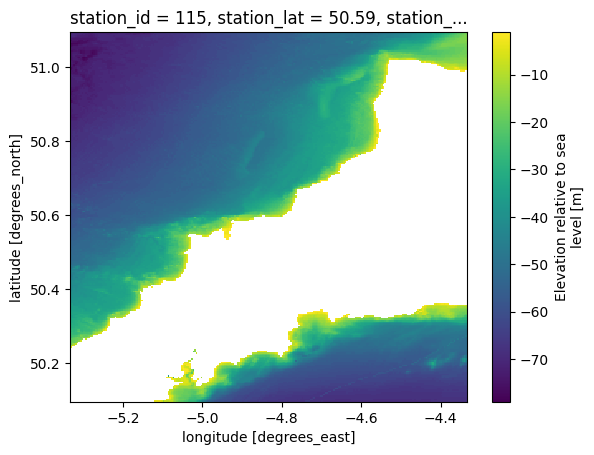

In [53]:
results_by_var["elevation"]["1x1"][10].elevation.plot()

In [ ]:
import numpy as np

R = 6371000.0

def directional_slope(tile, bearing_deg_to, station_lat=None, station_lon=None):
    """
    Directional slope at nearest gridpoint to station.
    bearing_deg_to: direction TOWARD which to project, degrees clockwise from north.

    Returns:
        g_par      : signed gradient along direction (m/m)
        slope_deg  : absolute slope angle in degrees
        lat0, lon0 : gridpoint actually used
    """

    # default to tile metadata if not supplied
    if station_lat is None:
        station_lat = float(tile.coords["station_lat"].values)
    if station_lon is None:
        station_lon = float(tile.coords["station_lon"].values)

    # bounds check
    lat_min = float(tile.lat.min())
    lat_max = float(tile.lat.max())
    lon_min = float(tile.lon.min())
    lon_max = float(tile.lon.max())

    if not (min(lat_min, lat_max) <= station_lat <= max(lat_min, lat_max)):
        return np.nan, np.nan, np.nan, np.nan
    if not (min(lon_min, lon_max) <= station_lon <= max(lon_min, lon_max)):
        return np.nan, np.nan, np.nan, np.nan

    # nearest indices manually (safer than .sel(..., method="nearest"))
    lat_idx = int(np.abs(tile.lat.values - station_lat).argmin())
    lon_idx = int(np.abs(tile.lon.values - station_lon).argmin())

    lat0 = float(tile.lat.values[lat_idx])
    lon0 = float(tile.lon.values[lon_idx])

    z = tile["elevation"]

    # need at least 3 points in each direction for stable gradient
    if z.sizes["lat"] < 3 or z.sizes["lon"] < 3:
        return np.nan, np.nan, lat0, lon0

    dlat = float(abs(tile.lat.diff("lat").mean()))
    dlon = float(abs(tile.lon.diff("lon").mean()))

    lat_rad = np.deg2rad(tile.lat)
    dy = dlat * np.pi / 180.0 * R
    dx = dlon * np.pi / 180.0 * R * np.cos(lat_rad)

    dz_dy = z.differentiate("lat") / dy
    dz_dx = z.differentiate("lon") / dx

    gx = float(dz_dx.isel(lat=lat_idx, lon=lon_idx).values)
    gy = float(dz_dy.isel(lat=lat_idx, lon=lon_idx).values)

    if np.isnan(gx) or np.isnan(gy):
        return np.nan, np.nan, lat0, lon0

    th = np.deg2rad(float(bearing_deg_to))
    ux = np.sin(th)   # east
    uy = np.cos(th)   # north

    g_par = gx * ux + gy * uy
    slope_deg = float(np.degrees(np.arctan(abs(g_par))))

    return g_par, slope_deg, lat0, lon0

import numpy as np

tile_lookup = {}  # (station, size_key) -> xr.Dataset tile that contains elevation

for size_key in sizes.keys():
    for tile in results_by_var["elevation"][size_key]:
        sid = tile.coords["station_id"].values
        sid = sid.item() if hasattr(sid, "item") else sid
        tile_lookup[(sid, size_key)] = tile

In [63]:
for idx, row in stats_df.iterrows():
    sid = row["station"]
    slat = float(row["lat"])
    slon = float(row["lon"])

    wind_bearing = row["wind_dir"]
    wave_bearing = row["mwd"]

    for size_key in sizes.keys():
        tile = tile_lookup.get((sid, size_key))
        if tile is None:
            continue

        if not pd.isna(wind_bearing):
            g, sdeg, _, _ = directional_slope(
                tile,
                bearing_deg_to=float(wind_bearing),
                station_lat=slat,
                station_lon=slon
            )
            stats_df.at[idx, f"grad_wind_{size_key}"] = g
            stats_df.at[idx, f"slope_wind_{size_key}"] = sdeg

        if not pd.isna(wave_bearing):
            g, sdeg, _, _ = directional_slope(
                tile,
                bearing_deg_to=float(wave_bearing),
                station_lat=slat,
                station_lon=slon
            )
            stats_df.at[idx, f"grad_wave_{size_key}"] = g
            stats_df.at[idx, f"slope_wave_{size_key}"] = sdeg

ValueError: zero-size array to reduction operation fmin which has no identity

In [60]:
import xarray as xr

R = 6371000.0

def directional_slope(tile, station_lat, station_lon, bearing_deg_to):
    """
    Directional slope at nearest gridpoint to (station_lat, station_lon)
    along bearing_deg_to (deg clockwise from north).

    Returns:
      g_par (m/m, signed), slope_deg (deg, >=0), used_lat, used_lon
    """
    # nearest gridpoint
    pt = tile.sel(lat=station_lat, lon=station_lon, method="nearest")
    lat0 = float(pt.lat)
    lon0 = float(pt.lon)

    z = tile["elevation"]

    # spacing in degrees (regular grid assumed)
    dlat = float(abs(tile.lat.diff("lat").mean()))
    dlon = float(abs(tile.lon.diff("lon").mean()))

    lat_rad = np.deg2rad(tile.lat)
    dy = dlat * np.pi/180 * R
    dx = dlon * np.pi/180 * R * np.cos(lat_rad)

    dz_dy = z.differentiate("lat") / dy
    dz_dx = z.differentiate("lon") / dx

    th = np.deg2rad(bearing_deg_to)
    ux = np.sin(th)  # east
    uy = np.cos(th)  # north

    gx = float(dz_dx.sel(lat=lat0, lon=lon0).values)
    gy = float(dz_dy.sel(lat=lat0, lon=lon0).values)

    g_par = gx * ux + gy * uy
    slope_deg = float(np.rad2deg(np.arctan(abs(g_par))))

    return g_par, slope_deg, lat0, lon0

In [57]:
import numpy as np

tile_lookup = {}  # (station, size_key) -> xr.Dataset tile that contains elevation

for size_key in sizes.keys():
    for tile in results_by_var["elevation"][size_key]:
        sid = tile.coords["station_id"].values
        sid = sid.item() if hasattr(sid, "item") else sid
        tile_lookup[(sid, size_key)] = tile

In [61]:
import pandas as pd

# choose which direction columns to use:
# - wind: I'd use wind_to_mean_deg (already "to")
# - wave: depends on mwd definition; many wave datasets use "from". If unsure, keep both or convert.
WIND_COL = "wind_to_mean_deg" if "wind_to_mean_deg" in stats_df.columns else "wind_dir"
WAVE_COL = "mwd"

# initialize output columns
for size_key in sizes.keys():
    stats_df[f"slope_wind_{size_key}"] = np.nan
    stats_df[f"slope_wave_{size_key}"] = np.nan
    stats_df[f"grad_wind_{size_key}"] = np.nan   # signed m/m
    stats_df[f"grad_wave_{size_key}"] = np.nan

# loop rows (timestamped)
for idx, row in stats_df.iterrows():
    sid = row["station"]
    slat = float(row["lat"])
    slon = float(row["lon"])

    wind_bearing = row[WIND_COL]
    wave_bearing = row[WAVE_COL]

    # skip missing directions
    if pd.isna(wind_bearing) and pd.isna(wave_bearing):
        continue

    for size_key in sizes.keys():
        tile = tile_lookup.get((sid, size_key), None)
        if tile is None:
            continue

        # wind directional slope
        if not pd.isna(wind_bearing):
            g, sdeg, _, _ = directional_slope(tile, slat, slon, float(wind_bearing))
            stats_df.at[idx, f"grad_wind_{size_key}"] = g
            stats_df.at[idx, f"slope_wind_{size_key}"] = sdeg

        # wave directional slope
        if not pd.isna(wave_bearing):
            g, sdeg, _, _ = directional_slope(tile, slat, slon, float(wave_bearing))
            stats_df.at[idx, f"grad_wave_{size_key}"] = g
            stats_df.at[idx, f"slope_wave_{size_key}"] = sdeg

KeyError: "not all values found in index 'lat'"

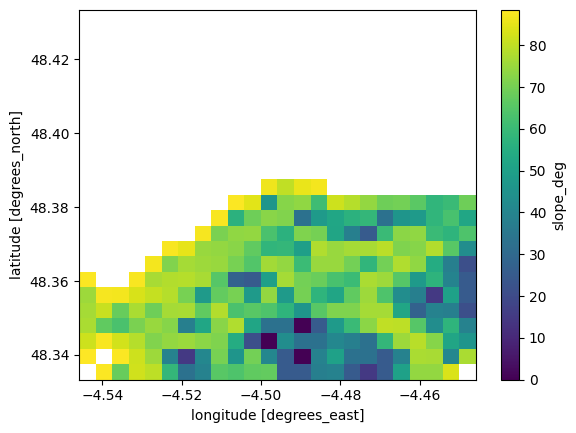

In [28]:
results_by_var["slope_deg"]["0.1x0.1"][0].slope_deg.plot()

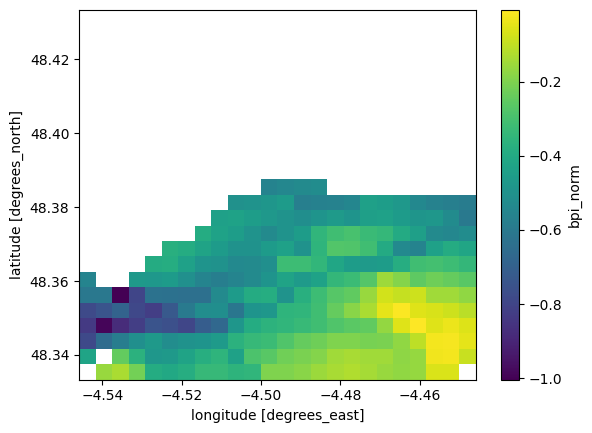

In [32]:
results_by_var["bpi_norm"]["0.1x0.1"][0].bpi_norm.plot()

In [9]:
results_all["1x1"][0].slope_deg.plot()

IndexError: list index out of range

In [12]:
def plot_tile_var(ds_tile, var, title=None, mask_shallow=False):
    da = ds_tile[var]

    if mask_shallow and var == "elevation":
        da = da.where(da <= -0.5)

    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    pcm = ax.pcolormesh(ds_tile["lon"], ds_tile["lat"], da, transform=ccrs.PlateCarree())
    ax.coastlines(resolution="10m")
    ax.set_extent([float(ds_tile.lon.min()), float(ds_tile.lon.max()),
                   float(ds_tile.lat.min()), float(ds_tile.lat.max())],
                  crs=ccrs.PlateCarree())

    ax.set_title(title or f"{var}")
    plt.colorbar(pcm, ax=ax, label=var)
    plt.show()
    
plot_tile_var(results_by_var["slope_deg"]["3x3"][0], "slope_deg",  mask_shallow=True)
plot_tile_var(results_by_var["elevation"]["3x3"][0], "elevation", mask_shallow=True)

IndexError: list index out of range

In [ ]:

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    ds_masked = ds_tile.copy()
    ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)
    return ds_masked

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg, var="elevation"):
    half = size_deg / 2

    lat0, lat1 = lat - half, lat + half
    lon0, lon1 = lon - half, lon + half

    # lat slice direction safe
    lat_slice = slice(lat0, lat1) if ds.lat[0] < ds.lat[-1] else slice(lat1, lat0)
    lon_slice = slice(lon0, lon1)

    return ds.sel(lat=lat_slice, lon=lon_slice)

for lat, lon in unique_latlon:
    results["0.1x0.1"].append(extract_square(GEBCO_ds, lat, lon, 0.1))
    results["0.25x0.25"].append(extract_square(GEBCO_ds, lat, lon, 0.25))
    results["1x1"].append(extract_square(GEBCO_ds, lat, lon, 1))
    results["3x3"].append(extract_square(GEBCO_ds, lat, lon, 3))
    results["10x10"].append(extract_square(GEBCO_ds, lat, lon, 10))

Plotting 3 tiles from 0.1x0.1


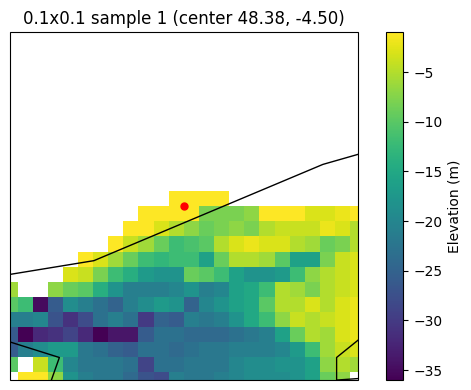

Skipping 0.1x0.1 tile 2: lat=0, lon=24


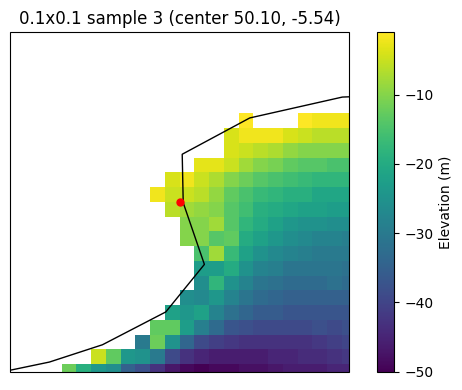

Plotting 3 tiles from 0.25x0.25


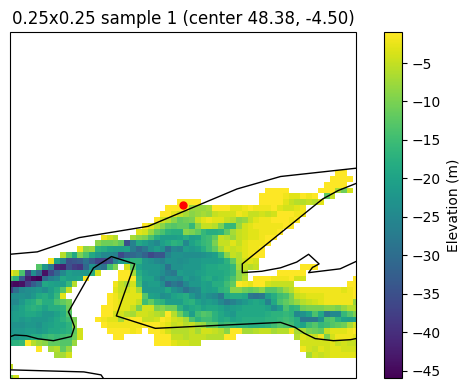

Skipping 0.25x0.25 tile 2: lat=0, lon=60


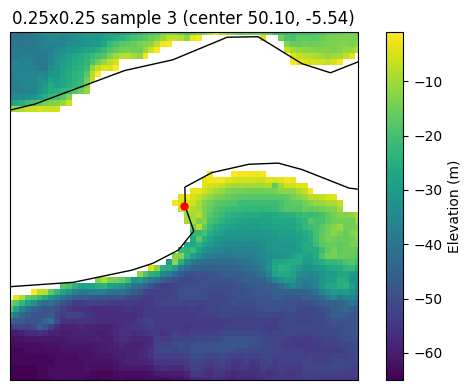

Plotting 3 tiles from 1x1


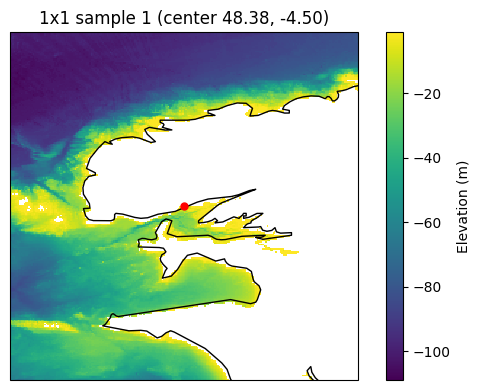

Skipping 1x1 tile 2: lat=0, lon=240


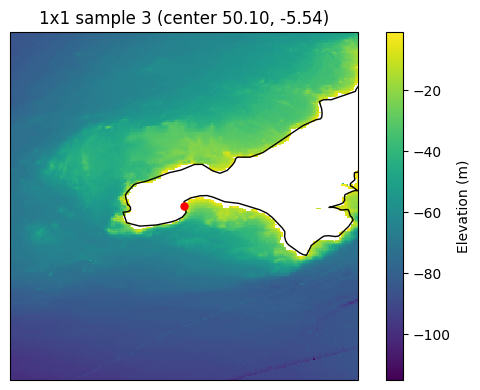

Plotting 3 tiles from 3x3


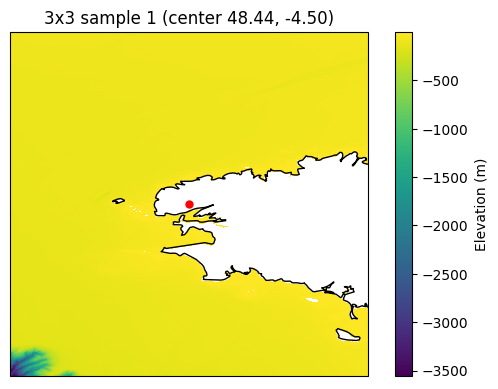

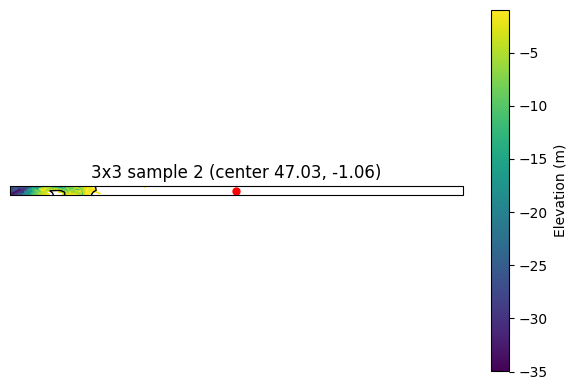

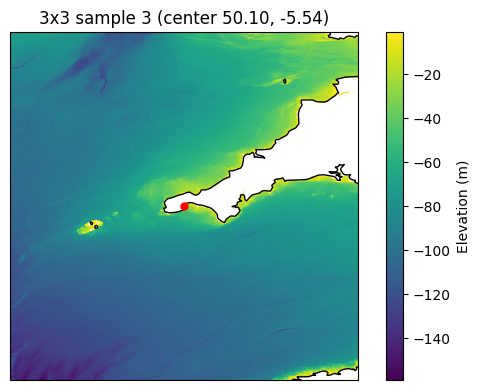

Plotting 3 tiles from 10x10


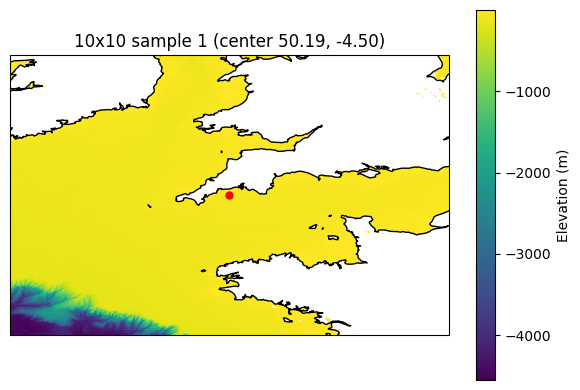

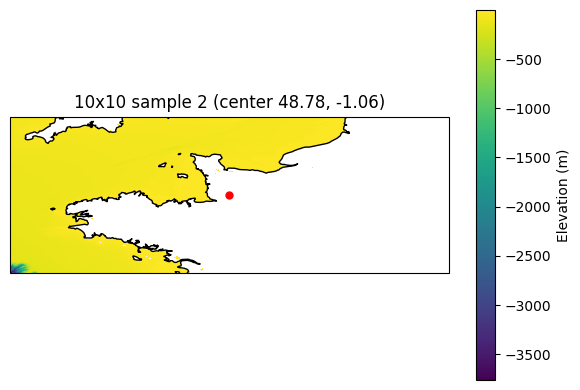

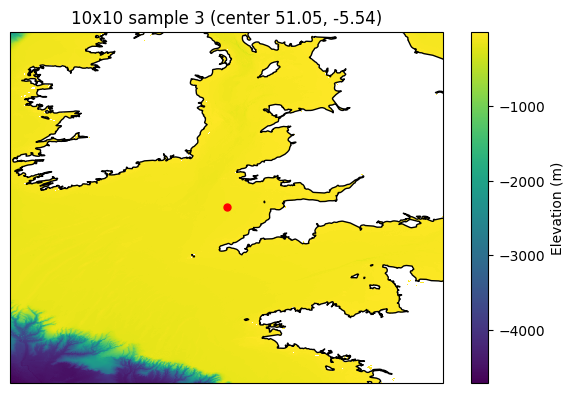

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def plot_results_bathymetry(results, max_per_size=3):
    for key, tiles in results.items():
        if not tiles:
            print(f"No tiles in {key}")
            continue

        print(f"Plotting {min(len(tiles), max_per_size)} tiles from {key}")
        for i, ds_tile in enumerate(tiles[:max_per_size]):

            # mask shallow elevations
            ds_masked = ds_tile.copy()
            ds_masked["elevation"] = ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5)

            # guard against empty/degenerate tiles
            lat_n = ds_masked.dims.get("lat", 0)
            lon_n = ds_masked.dims.get("lon", 0)
            if lat_n < 2 or lon_n < 2:
                print(f"Skipping {key} tile {i+1}: lat={lat_n}, lon={lon_n}")
                continue

            # tile center (coordinate midpoint, not necessarily station)
            center_lat = float(ds_masked["lat"].values.mean())
            center_lon = float(ds_masked["lon"].values.mean())

            fig = plt.figure(figsize=(6, 4))
            ax = plt.axes(projection=ccrs.PlateCarree())

            LON, LAT = np.meshgrid(ds_masked["lon"].values, ds_masked["lat"].values)
            Z = ds_masked["elevation"].values

            pcm = ax.pcolormesh(
                LON, LAT, Z,
                transform=ccrs.PlateCarree(),
                shading="auto"
            )

            ax.coastlines(resolution="10m")
            ax.set_extent(
                [float(ds_masked.lon.min()), float(ds_masked.lon.max()),
                 float(ds_masked.lat.min()), float(ds_masked.lat.max())],
                crs=ccrs.PlateCarree()
            )

            ax.set_title(f"{key} sample {i+1} (center {center_lat:.2f}, {center_lon:.2f})")
            ax.plot(center_lon, center_lat, "ro", markersize=5, transform=ccrs.PlateCarree())

            plt.colorbar(pcm, ax=ax, label="Elevation (m)")
            plt.tight_layout()
            plt.show()

# Example usage
plot_results_bathymetry(results, max_per_size=3)

In [ ]:
stats_df.lon.head()

0   -4.495
1   -4.495
2   -4.495
3   -4.495
4   -4.495
Name: lon, dtype: float64

near 0 wind is close to cross-shore/onshore

In [ ]:
stats_df.to_csv("DIff_GEV_station_variable_statistics.csv", index=False)

In [ ]:
import pandas as pd

def column_catalog(stats_df: pd.DataFrame) -> pd.DataFrame:
    cols = list(stats_df.columns)
    labels = pd.Series(index=cols, dtype="object")

    # ---- rules (in precedence order) ----

    # LOCATION
    for c in ("station", "lon", "lat"):
        if c in labels.index:
            labels.loc[c] = "LOCATION"

    # SEALEVEL_TARGET: anything containing "residual"
    residual_cols = [c for c in cols if "residual" in c.lower()]
    labels.loc[residual_cols] = "SEALEVEL_TARGET"

    # RELATIVE_BAY: anything with degrees
    deg_cols = [c for c in cols if c.endswith("_deg")]
    labels.loc[deg_cols] = "RELATIVE_BAY"

    # WEATHER: ERA5 vars + derivatives of those vars (e.g., u10_abs, tau_u_abs, etc.)
    era5_bases = ["u10", "v10", "d2m", "t2m", "msl", "sst", "sp", "tp", "mwd", "mwp", "swh"]
    weather_cols = []
    for c in cols:
        c_low = c.lower()
        if c in era5_bases:
            weather_cols.append(c)
            continue
        # derivatives like u10_abs, v10_abs, tp_something, etc.
        if any(c.startswith(base + "_") for base in era5_bases):
            weather_cols.append(c)
            continue
        # common derived-from-wind/wave diagnostics present in your df
        if c_low.startswith(("tau_", "wind_")) or c_low in ("wind_dir",):
            weather_cols.append(c)
            continue

    # Only set WEATHER where not already set by higher-precedence rules
    for c in weather_cols:
        if pd.isna(labels.loc[c]):
            labels.loc[c] = "WEATHER"

    # everything else
    labels = labels.fillna("OTHER")

    # return a tidy table "next to" the column names
    return pd.DataFrame({"column": labels.index, "label": labels.values})


# usage
catalog_df = column_catalog(stats_df)